In [1]:
%load_ext autoreload
%autoreload 2
import duckdb
import geopandas as gpd
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterix
import seaborn as sns
import xarray as xr
from ibicus.debias import QuantileMapping
from rasterix.rasterize.rasterio import geometry_clip

import sys
from pathlib import Path

# local_src = "/scratch/synced/src"  
# sys.path.insert(0, local_src)

# for m in list(sys.modules):
#     if m == "srm" or m.startswith("srm."):
#         del sys.modules[m]

import srm
from srm import catalog
from srm.utils import icechunk_store_to_dataset, clean_up_dataset, convert_precip_units,rename_coords
from srm.plotting import (
    plot_comparisons, calculate_statistic_to_plot,
    prep_datasets_for_daily_timeseries_plotting,
    prep_datasets_for_seasonal_cycle_plotting,
    plot_timeseries, sel_point, plot_pdf, plot_cdf
)

In [2]:
ds1 = xr.open_dataset('s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_nonparametric.nc', engine='h5netcdf')
ds2 = xr.open_dataset('s3://carbonplan-srm/output/v0.2/pr_model_hist_BCSD_parametric.nc', engine='h5netcdf')
# rename latitude = lat; longitude = lon
ds1=ds1.swap_dims({'longitude': 'lon', 'latitude' : 'lat'})
ds2=ds2.swap_dims({'longitude': 'lon', 'latitude' : 'lat'})

In [3]:
print("DS1 extent:")
print(f"  Lat: {ds1.lat.min().values} to {ds1.lat.max().values}")
print(f"  Lon: {ds1.lon.min().values} to {ds1.lon.max().values}")

print("\nDS2 extent:")
print(f"  Lat: {ds2.lat.min().values} to {ds2.lat.max().values}")
print(f"  Lon: {ds2.lon.min().values} to {ds2.lon.max().values}")

DS1 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75

DS2 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75


In [4]:
variables = ["pr", "tas"]

In [5]:
era5 = icechunk_store_to_dataset("ERA5", catalog)
era5

<xarray.Dataset> Size: 789GB
Dimensions:      (time: 23741, lat: 721, lon: 1440, bounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 190kB 1950-01-01 ... 2014-12-31
  * lat          (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float32 6kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    lat_bounds   (lat, bounds) float32 6kB dask.array<chunksize=(35, 2), meta=np.ndarray>
    lon_bounds   (lon, bounds) float32 12kB dask.array<chunksize=(70, 2), meta=np.ndarray>
    time_bounds  (time, bounds) datetime64[ns] 380kB dask.array<chunksize=(23741, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    tasmin       (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    rlds         (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    ps           (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    rsds         (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    tasmax       (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    pr           (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    tas          (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
    sfcWind      (time, lat, lon) float32 99GB dask.array<chunksize=(23741, 7, 14), meta=np.ndarray>
Attributes:
    last_updated:           2025-12-19 02:01:39.437181+00:00
    valid_time_start:       1950-01-01
    valid_time_stop:        2014-12-31
    valid_time_stop_era5t:  2025-12-13

In [6]:
gcm = "CESM2-WACCM" # TODO - once dataset name is fixed this should update to CESM2
scenario = "Historical"# "SSP245" # #  # "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
ensemble_member='007'
# TODO: make the training period an attr in the dataset
training_period = slice("1978-01-01", "2014-12-31") 
# this will restrict the domain to the spatial extent of ds1
lon_max, lon_min = ds1.longitude.max().values, ds1.longitude.min().values
lat_max, lat_min = ds1.latitude.max().values, ds1.latitude.min().values

In [7]:
raw = icechunk_store_to_dataset(dataset_name, catalog)
raw

<xarray.Dataset> Size: 30GB
Dimensions:      (time: 13521, lat: 192, lon: 288, bounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 108kB 1978-01-01 ... 2015-01-16
  * lat          (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon          (lon) float64 2kB -180.0 -178.8 -177.5 ... 176.2 177.5 178.8
    lon_bounds   (lon, bounds) float64 5kB dask.array<chunksize=(64, 2), meta=np.ndarray>
    lat_bounds   (lat, bounds) float64 3kB dask.array<chunksize=(32, 2), meta=np.ndarray>
    time_bounds  (time, bounds) datetime64[ns] 216kB dask.array<chunksize=(13521, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    ps           (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    huss         (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    hurs         (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    rsds         (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    pr           (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    rlds         (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    tasmin       (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    tasmax       (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    sfcWind      (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
    tas          (time, lat, lon) float32 3GB dask.array<chunksize=(13521, 8, 16), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.8
    source:            CAM
    case:              b.e21.BWHISTcmip6.f09_g17.CMIP6-historical-WACCM.1980_...
    logname:           tilmes
    host:              cheyenne2
    initial_file:      b.e21.BWHIST.f09_g17.CMIP6-historical-WACCM.001.cam.i....
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1
    scenario:          historical
    model:             CESM2-WACCM

In [8]:
# for this set-up we'll convert precip units to all be on mm/day
ds1 = convert_precip_units(ds1, 'ERA5')
ds1 = ds1.drop('spatial_ref')
if ds2 is not None:
    ds2 = convert_precip_units(ds2, 'ERA5')
    ds2 = ds2.drop('spatial_ref')

/tmp/ipykernel_10503/4216431243.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds1 = ds1.drop('spatial_ref')
/tmp/ipykernel_10503/4216431243.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds2 = ds2.drop('spatial_ref')


In [9]:
variable=variables[0]

In [10]:
raw = raw.sel(time=training_period, 
              lat=slice(lat_min, lat_max), 
              lon=slice(lon_min, lon_max))
era5 = era5.sel(time=training_period, 
              lat=slice(lat_min, lat_max), 
              lon=slice(lon_min, lon_max))
ds1 = ds1.sel(time=training_period)
ds2 = ds2.sel(time=training_period)

In [11]:
print("DS1 extent:")
print(f"  Lat: {ds1.lat.min().values} to {ds1.lat.max().values}")
print(f"  Lon: {ds1.lon.min().values} to {ds1.lon.max().values}")

print("\nDS2 extent:")
print(f"  Lat: {ds2.lat.min().values} to {ds2.lat.max().values}")
print(f"  Lon: {ds2.lon.min().values} to {ds2.lon.max().values}")

DS1 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75

DS2 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75


In [12]:
# team TODO: remove this temporal subsetting *once this notebook development complete* (i.e. when merging into main). 
# i include it now because while in development, it's helpful to subset to a single year to 
# speed up the processing and make it easier to run repeatedly 
raw_pr_toplot, era5_pr_toplot, ds1_pr_toplot, ds2_pr_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1.isel(time=slice(0, 365)),
                                                                              'mean',
                                                                              'pr',
                                                                              ds2=ds2.isel(time=slice(0, 365)))

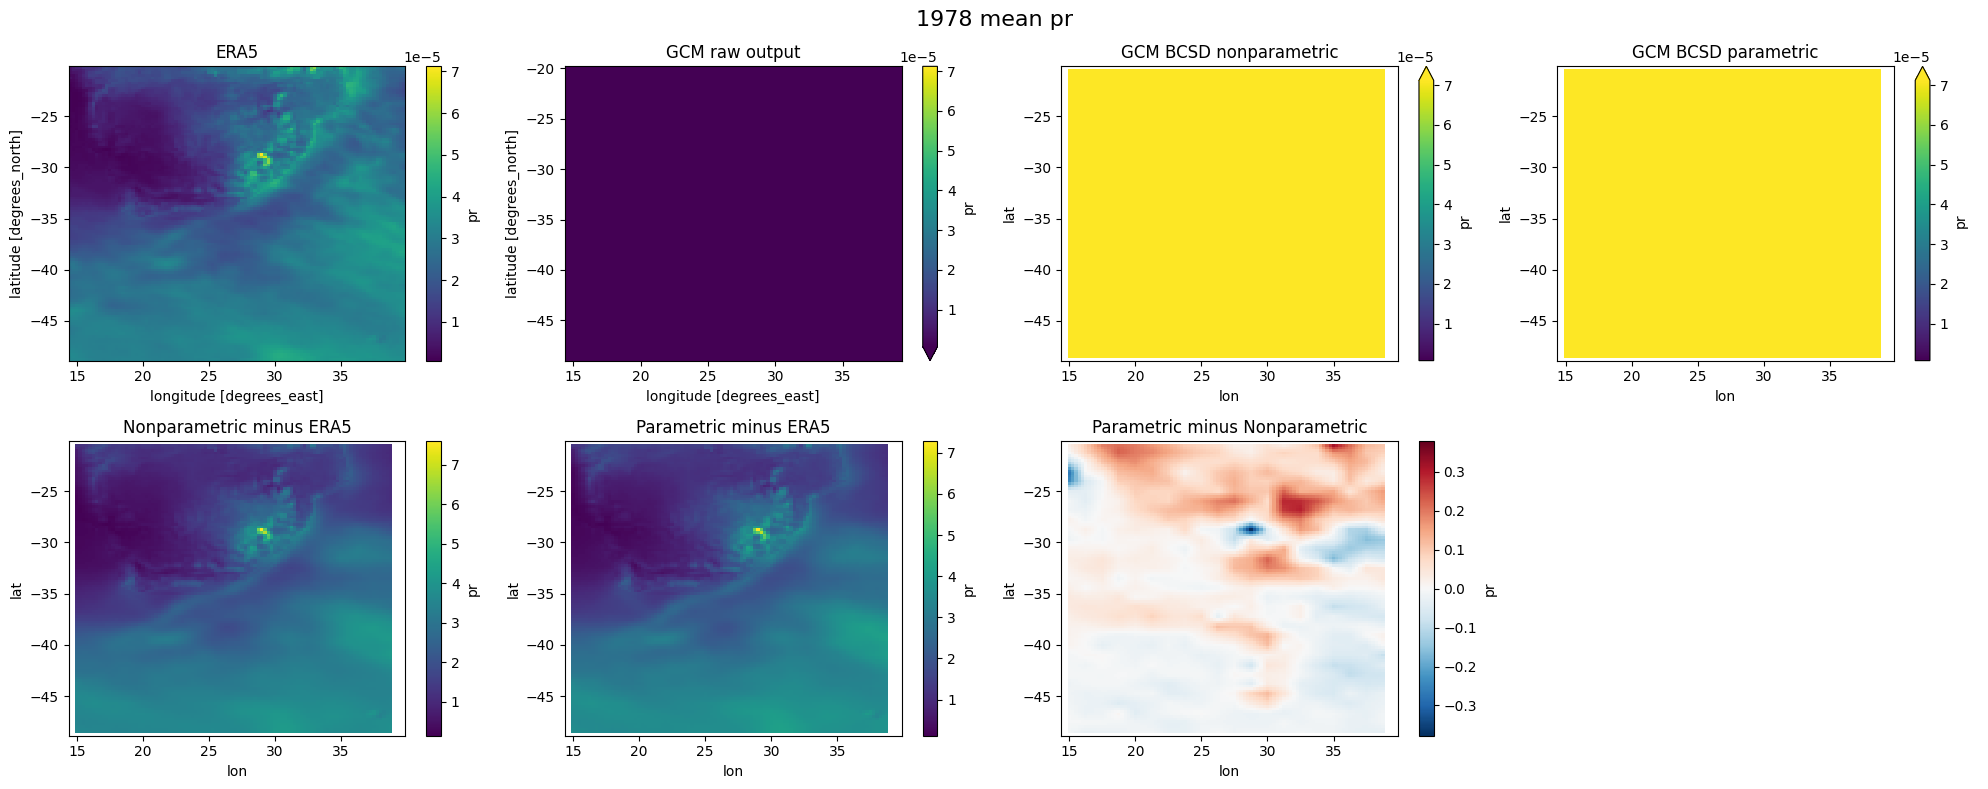

In [13]:
plot_comparisons(era5_pr_toplot, raw_pr_toplot, ds1_pr_toplot, ds2_pr_toplot)

In [14]:
raw_99p_toplot, era5_99p_toplot, ds1_99p_toplot, ds2_99p_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1.isel(time=slice(0, 365)),
                                                                              '99p',
                                                                              'pr',
                                                                              ds2=ds2.isel(time=slice(0, 365)))

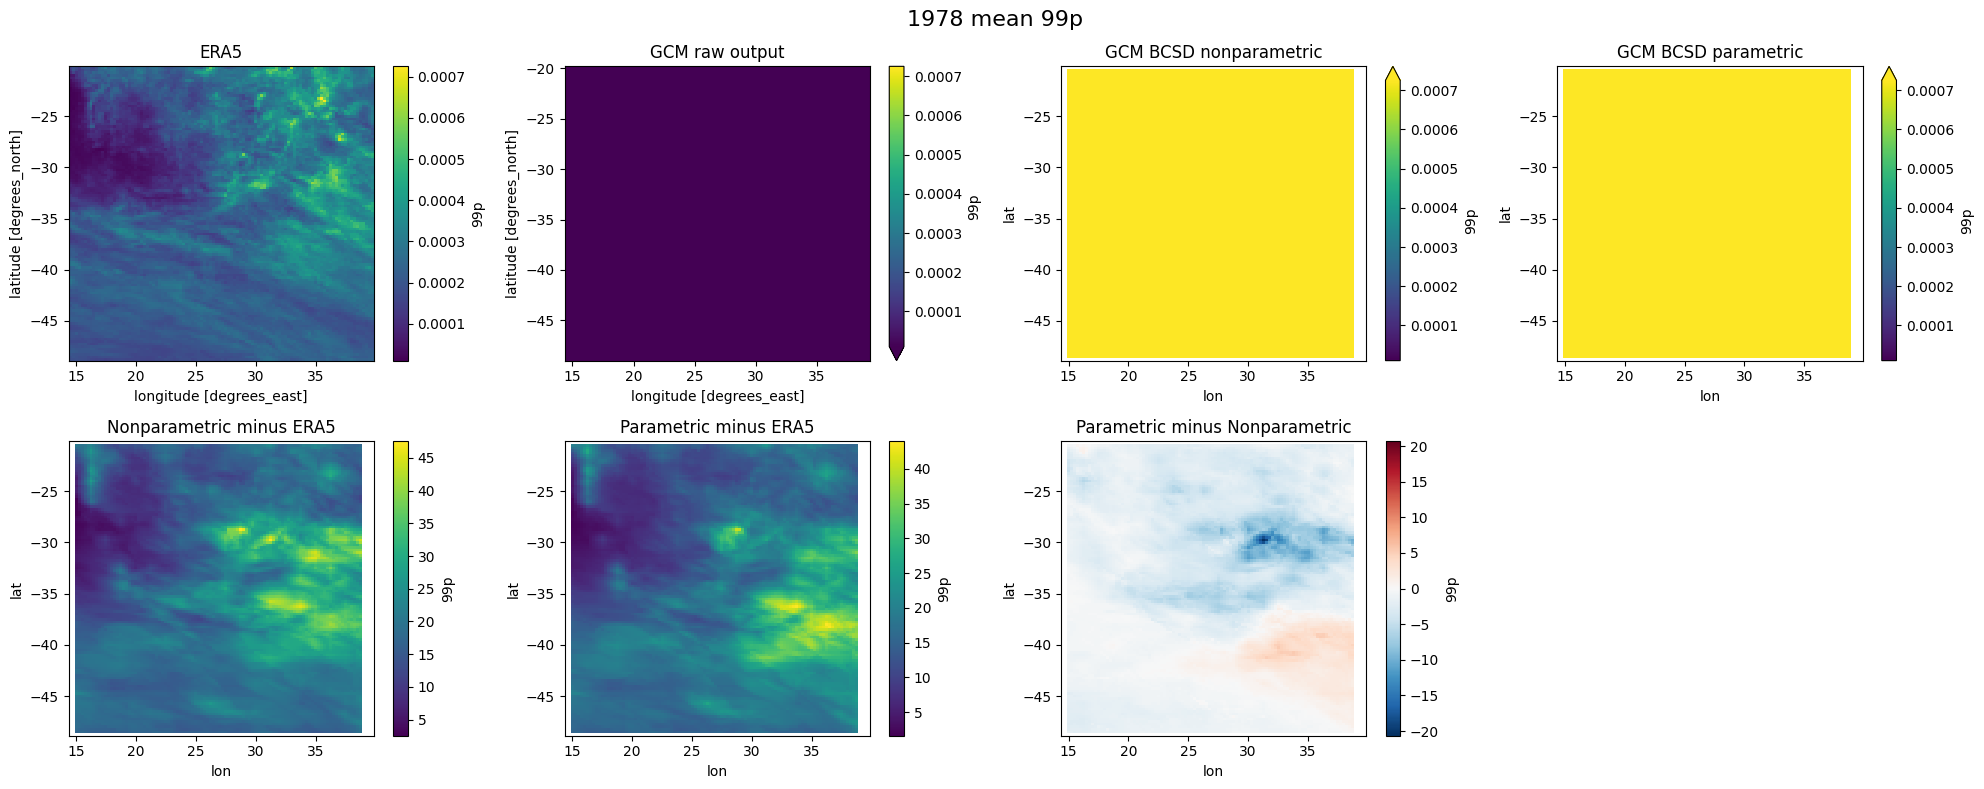

In [15]:
plot_comparisons(era5_99p_toplot, raw_99p_toplot, ds1_99p_toplot, ds2_99p_toplot)

In [16]:
raw_dd_toplot, era5_dd_toplot, ds1_dd_toplot, ds2_dd_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1.isel(time=slice(0, 365)),
                                                                              'dry_days',
                                                                              'pr',
                                                                              ds2=ds2.isel(time=slice(0, 365)))

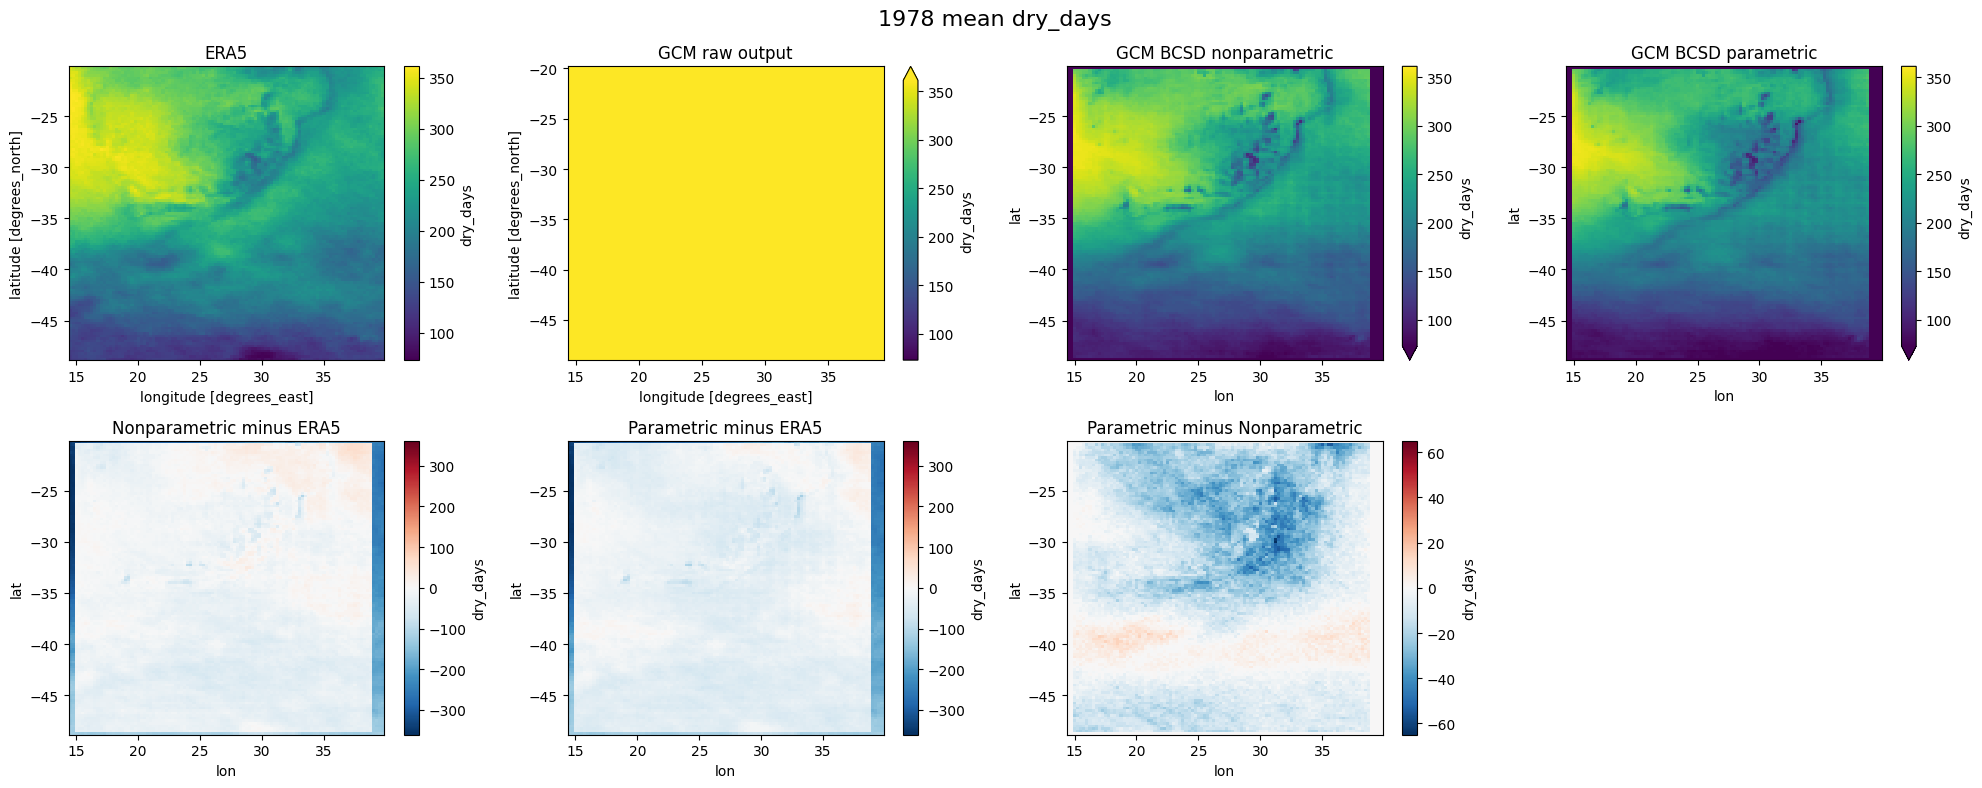

In [17]:
plot_comparisons(era5_dd_toplot, raw_dd_toplot, ds1_dd_toplot, ds2_dd_toplot)

In [18]:
#Now plot temperature variables
ds1_tas = xr.open_dataset('s3://carbonplan-srm/output/v0.2/tas_model_hist_BCSD_nonparametric.nc', engine='h5netcdf')
ds2_tas = xr.open_dataset('s3://carbonplan-srm/output/v0.2/tas_model_hist_BCSD_parametric.nc', engine='h5netcdf')

In [19]:
ds1_tas = ds1_tas.sel(time=training_period)
ds2_tas = ds2_tas.sel(time=training_period)

In [20]:
raw_tas_toplot, era5_tas_toplot, ds1_tas_toplot, ds2_tas_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1_tas.isel(time=slice(0, 365)),
                                                                              'mean',
                                                                              'tas',
                                                                              ds2=ds2_tas.isel(time=slice(0, 365)))

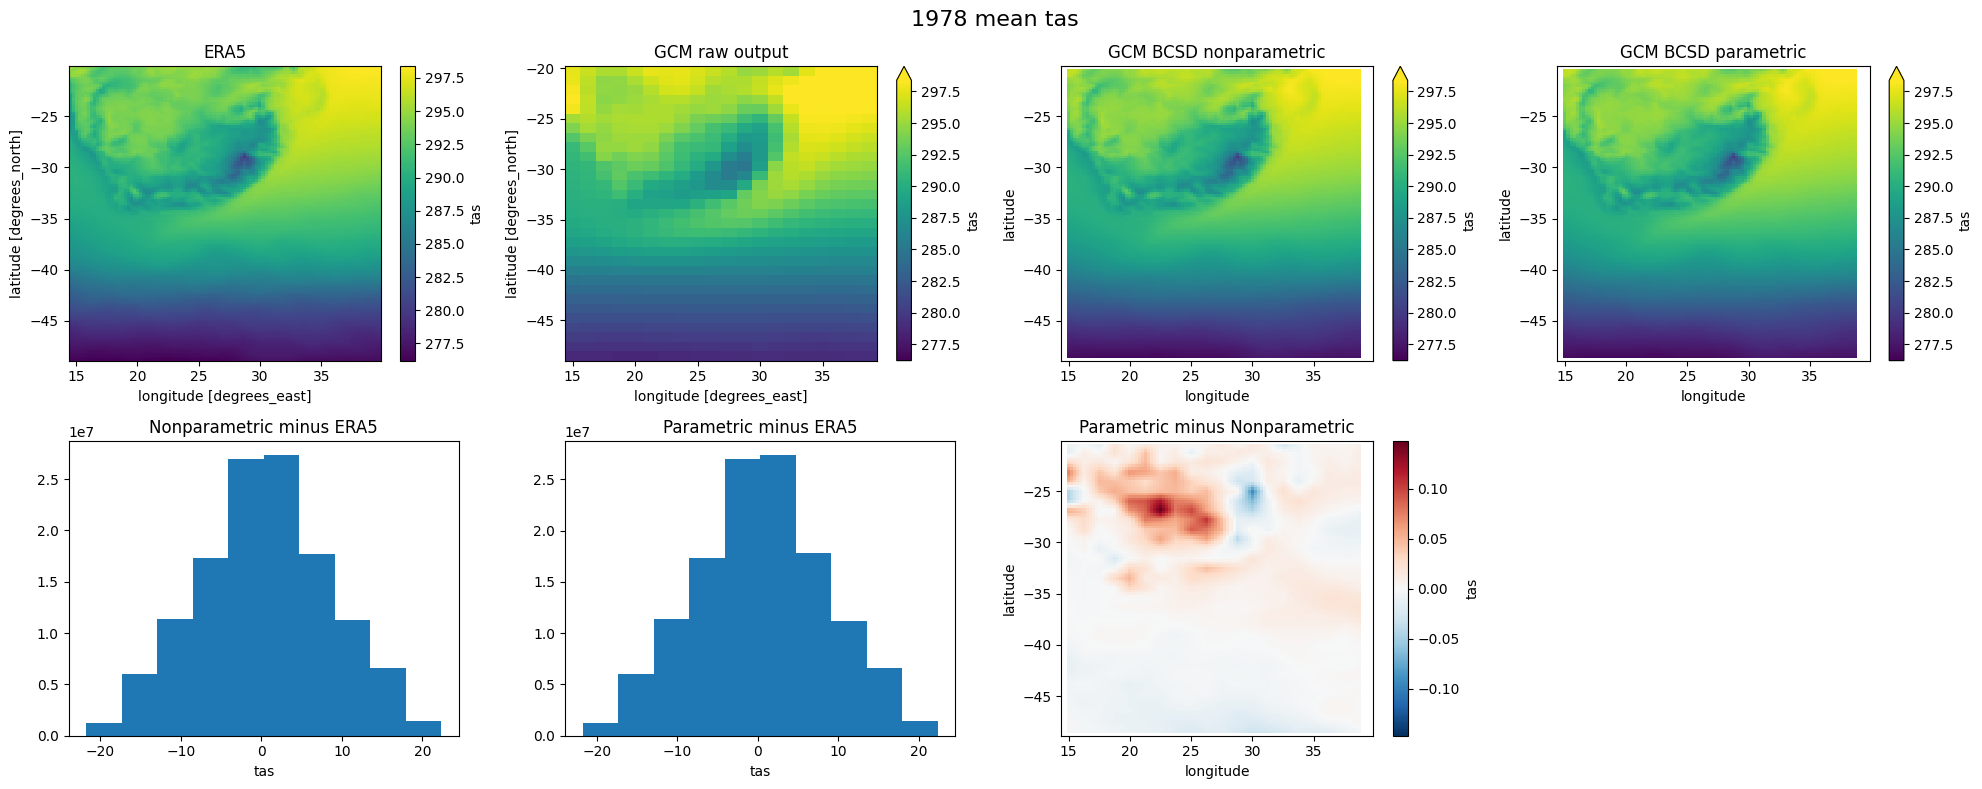

In [21]:
plot_comparisons(era5_tas_toplot, raw_tas_toplot, ds1_tas_toplot, ds2_tas_toplot)

In [22]:
raw_hot_day_toplot, era5_hot_day_toplot, ds1_hot_day_toplot, ds2_hot_day_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1_tas.isel(time=slice(0, 365)),
                                                                              'hottest_day',
                                                                              'tas',
                                                                              ds2=ds2_tas.isel(time=slice(0, 365)))

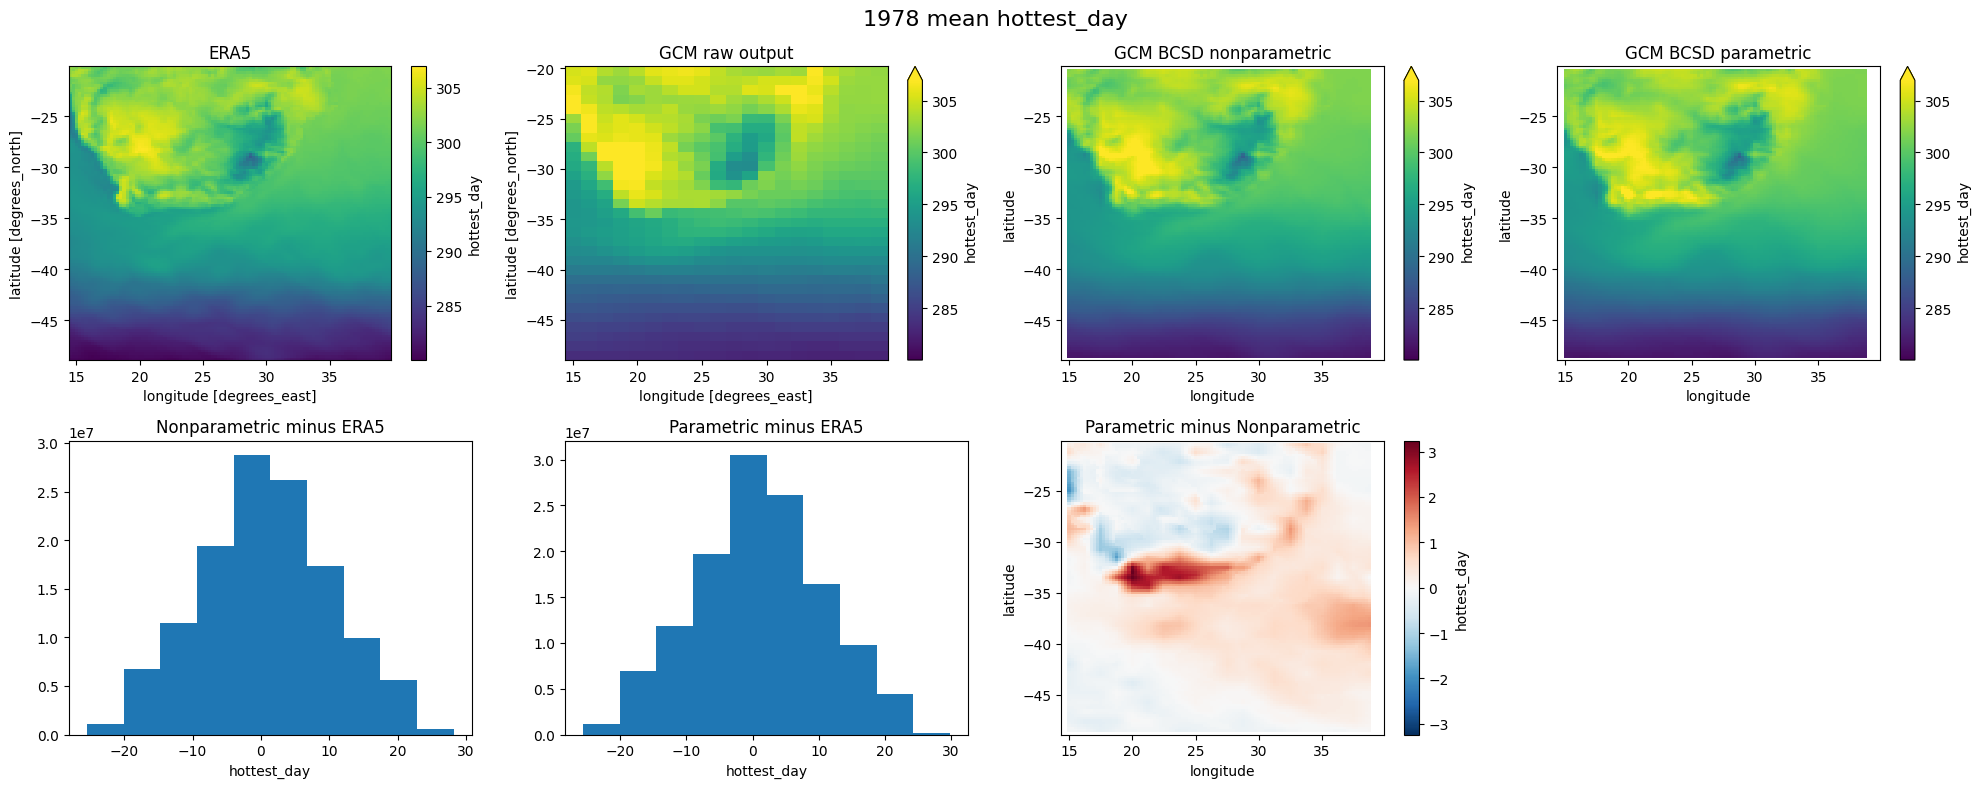

In [23]:
plot_comparisons(era5_hot_day_toplot, raw_hot_day_toplot, ds1_hot_day_toplot, ds2_hot_day_toplot)

In [24]:
raw_gdd_toplot, era5_gdd_toplot, ds1_gdd_toplot, ds2_gdd_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1_tas.isel(time=slice(0, 365)),
                                                                              'gdd',
                                                                              'tas',
                                                                              ds2=ds2_tas.isel(time=slice(0, 365)))

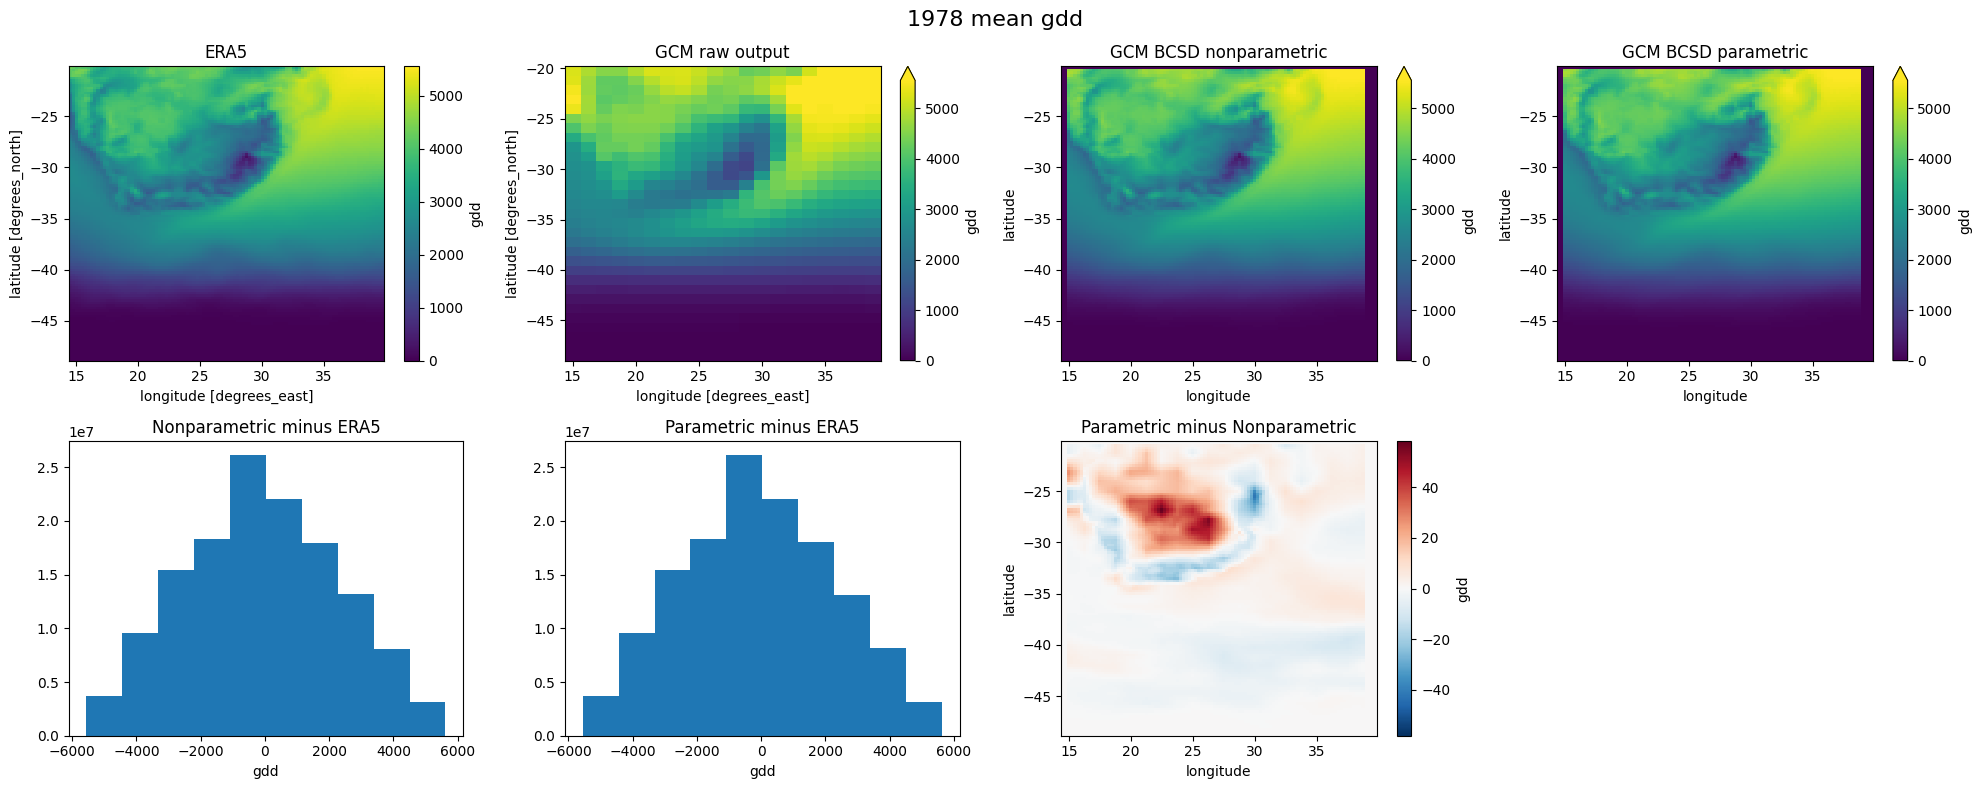

In [25]:
plot_comparisons(era5_gdd_toplot, raw_gdd_toplot, ds1_gdd_toplot, ds2_gdd_toplot)

In [26]:
raw_over30C_toplot, era5_over30C_toplot, ds1_over30C_toplot, ds2_over30C_toplot = calculate_statistic_to_plot(raw.isel(time=slice(0, 365)),
                                                                              
                                                                              era5.isel(time=slice(0, 365)),
                                                                              ds1_tas.isel(time=slice(0, 365)),
                                                                              'days_over_30C',
                                                                              'tas',
                                                                              ds2=ds2_tas.isel(time=slice(0, 365)))

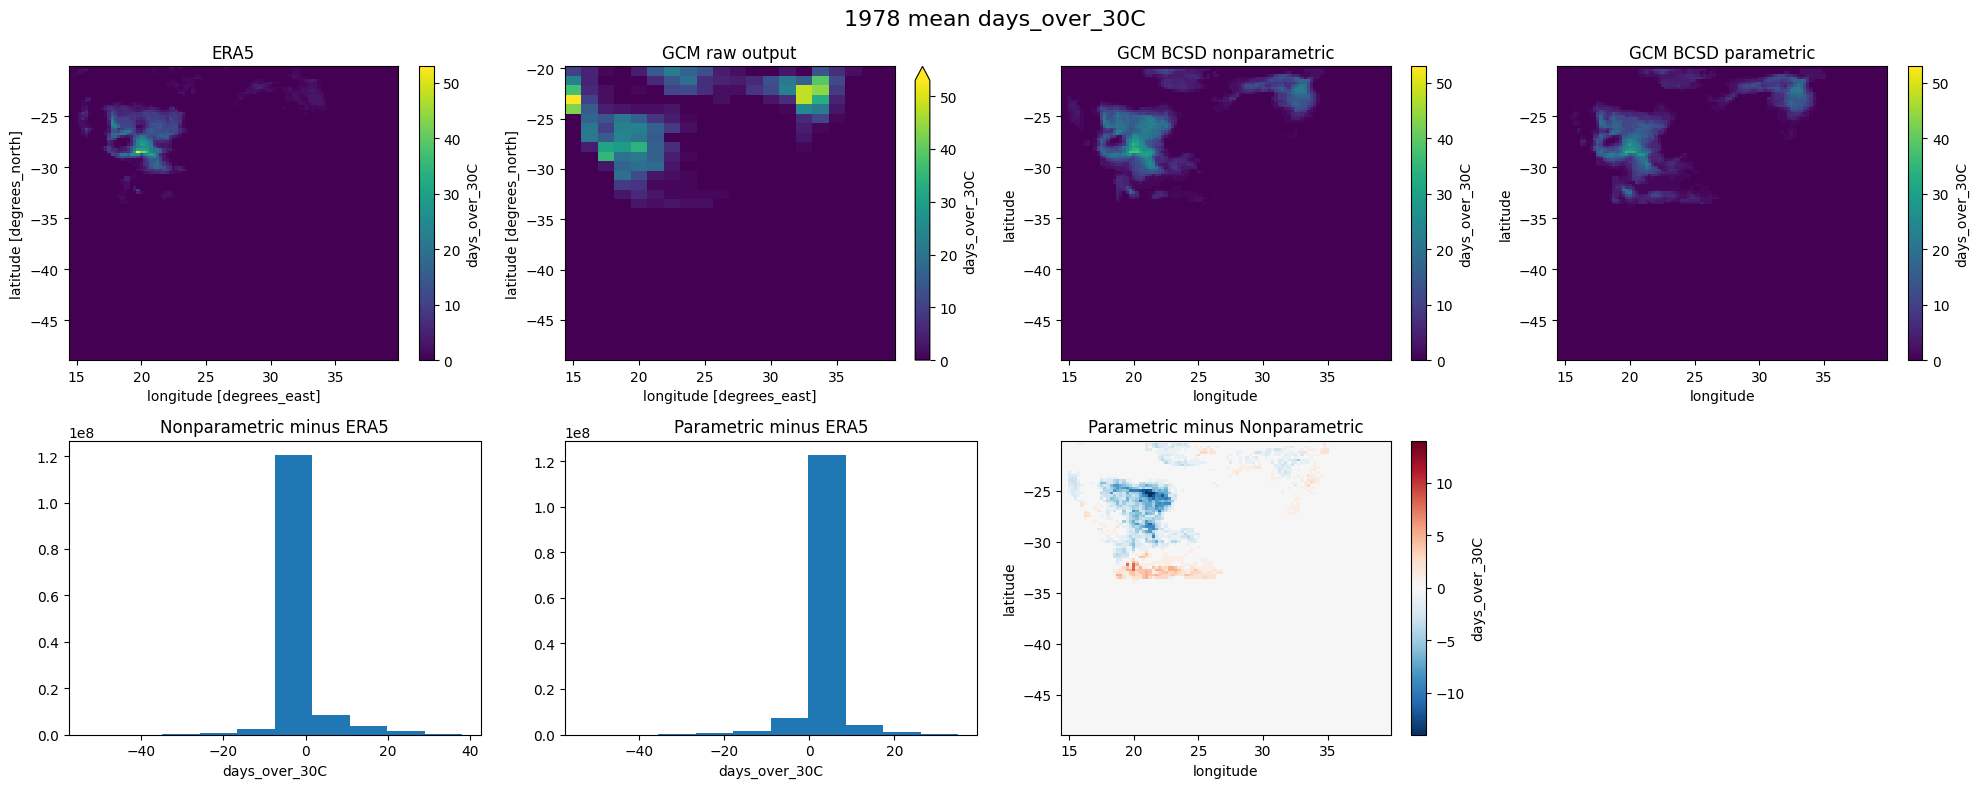

In [27]:
plot_comparisons(era5_over30C_toplot, raw_over30C_toplot, ds1_over30C_toplot, ds2_over30C_toplot)

In [28]:
locations = {'Cape Town': (-33.9221, 18.4231), 'Addis Ababa': (9.0192, 38.7525), 'Mumbai': (19.0728, 72.8826), 
                'Sao Paulo': (-23.5558, -46.6396), 'Berlin': (52.5200, 13.4050), 'New York': (40.7128, -74.0060),
                'Sydney': (-33.8727, 151.2057), 'Kyiv': (50.4504, 30.5245), 'Beijing': (39.9042, 116.4074),
                'Accra': (5.5593, -0.1974), 'Kualar Lumpur':(3.1319, 101.6841), 'Lagos': (6.6137, 3.3553),
                'Rio de Janerio': (-22.9068, -43.1729), 'Ankara': (39.9334, 32.8597), 'Cairo': (30.0444, 31.2357),
                'Melbourne': (-37.8136, 144.9631), 'Paris': (48.8575, 2.3514), 'Tokyo': (35.6764, 139.6500), 
                'Seoul': (37.5503, 126.9971), 'Chicago': (41.8832, -87.6324)
            # TODO Temi: add in 9 more major cities around the world
            # TODO Temi: add in 10 locations from a variety of climatic zones around the world
            }
Climatezones = {'Kualar Lumpur':(3.1319, 101.6841), 'Lagos': (6.6137, 3.3553), 'Rio de Janerio': (-22.9068, -43.1729),
                    'Ankara': (39.9334, 32.8597), 'Cairo': (30.0444, 31.2357), 'Melbourne': (-37.8136, 144.9631),
                    'Paris': (48.8575, 2.3514), 'Tokyo': (35.6764, 139.6500), 'Seoul': (37.5503, 126.9971), 
                    'Chicago': (41.8832, -87.6324)}

In [29]:
# temi TODO: write a description here for why we're doing this kind of analysis

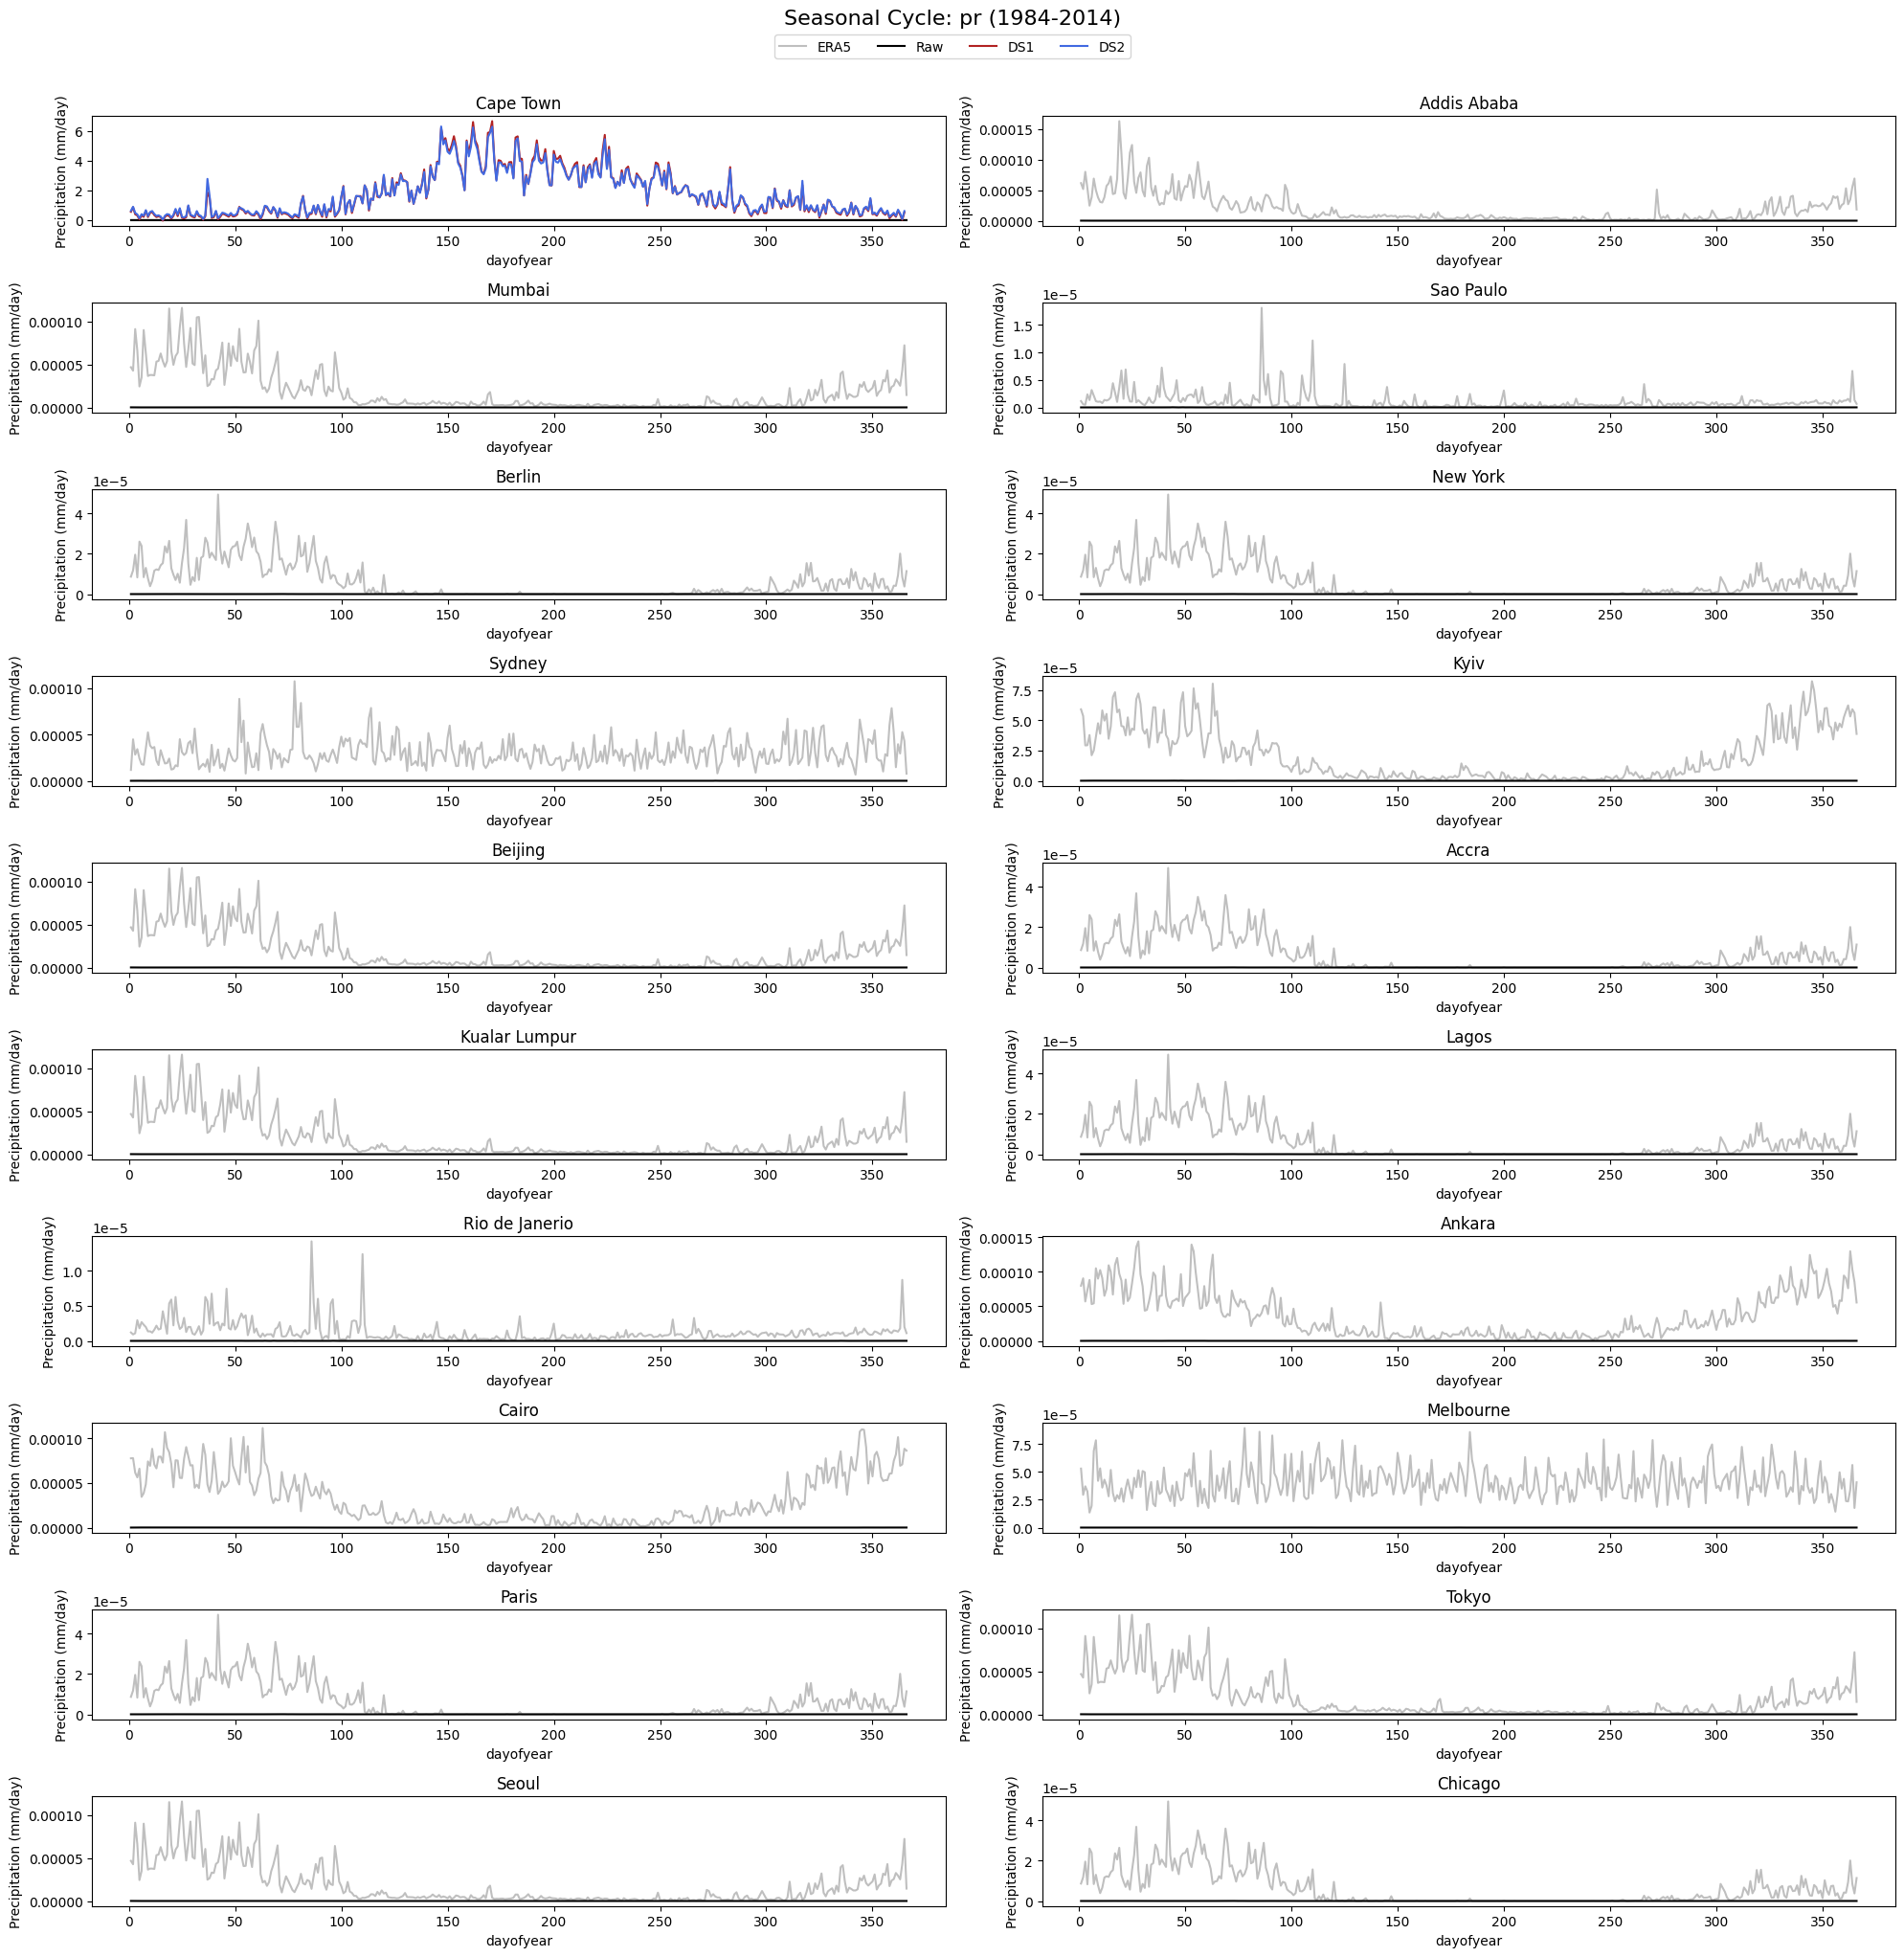

In [30]:
# temi TODO: add three more cells in this notebook, repeating these seasonal cycle plots for tasmax, tasmin, and tas 
variable = 'pr'
time_slice = slice('1984', '2014')

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20,20))
axarr = axarr_shape.flatten()
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_seasonal_cycle_plotting(era5, raw, ds1, 
                                                                                            time_slice, lat, 
                                                                                            lon, variable, ds2=ds2)

    plot_timeseries(axarr[i], era5_toplot, raw_toplot, ds1_toplot, location, ds2_toplot)
    axarr[i].set_title(location)
    axarr[i].set_ylabel('Precipitation (mm/day)')

fig.suptitle(f'Seasonal Cycle: {variable} ({time_slice.start}-{time_slice.stop})', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
    # temi TODO: add a single legend applying to all of the panels of plots, above the figure
    # temi TODO: add a title at the top of this figure (as part of the function) describing the variable and time period
    # temi TODO: fix ylabels to have units

In [31]:
print("ERA5 extent:")
print(f"  Lat: {float(era5.lat.min())} to {float(era5.lat.max())}")
print(f"  Lon: {float(era5.lon.min())} to {float(era5.lon.max())}")

print("\nRaw extent:")
print(f"  Lat: {float(raw.lat.min())} to {float(raw.lat.max())}")
print(f"  Lon: {float(raw.lon.min())} to {float(raw.lon.max())}")

print("\nDS1 extent:")
print(f"  Lat: {float(ds1.lat.min())} to {float(ds1.lat.max())}")
print(f"  Lon: {float(ds1.lon.min())} to {float(ds1.lon.max())}")

ERA5 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75

Raw extent:
  Lat: -48.53403141361257 to -20.261780104712045
  Lon: 15.0 to 38.75

DS1 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75


In [32]:
# Make a figure with all of the timeseries for all of the locations for the same time slice
# Repeat for a randomly selected year - for ease of calendar use only choose non-leap year calendars

In [33]:
ds_list = [era5, raw, ds1, ds2]

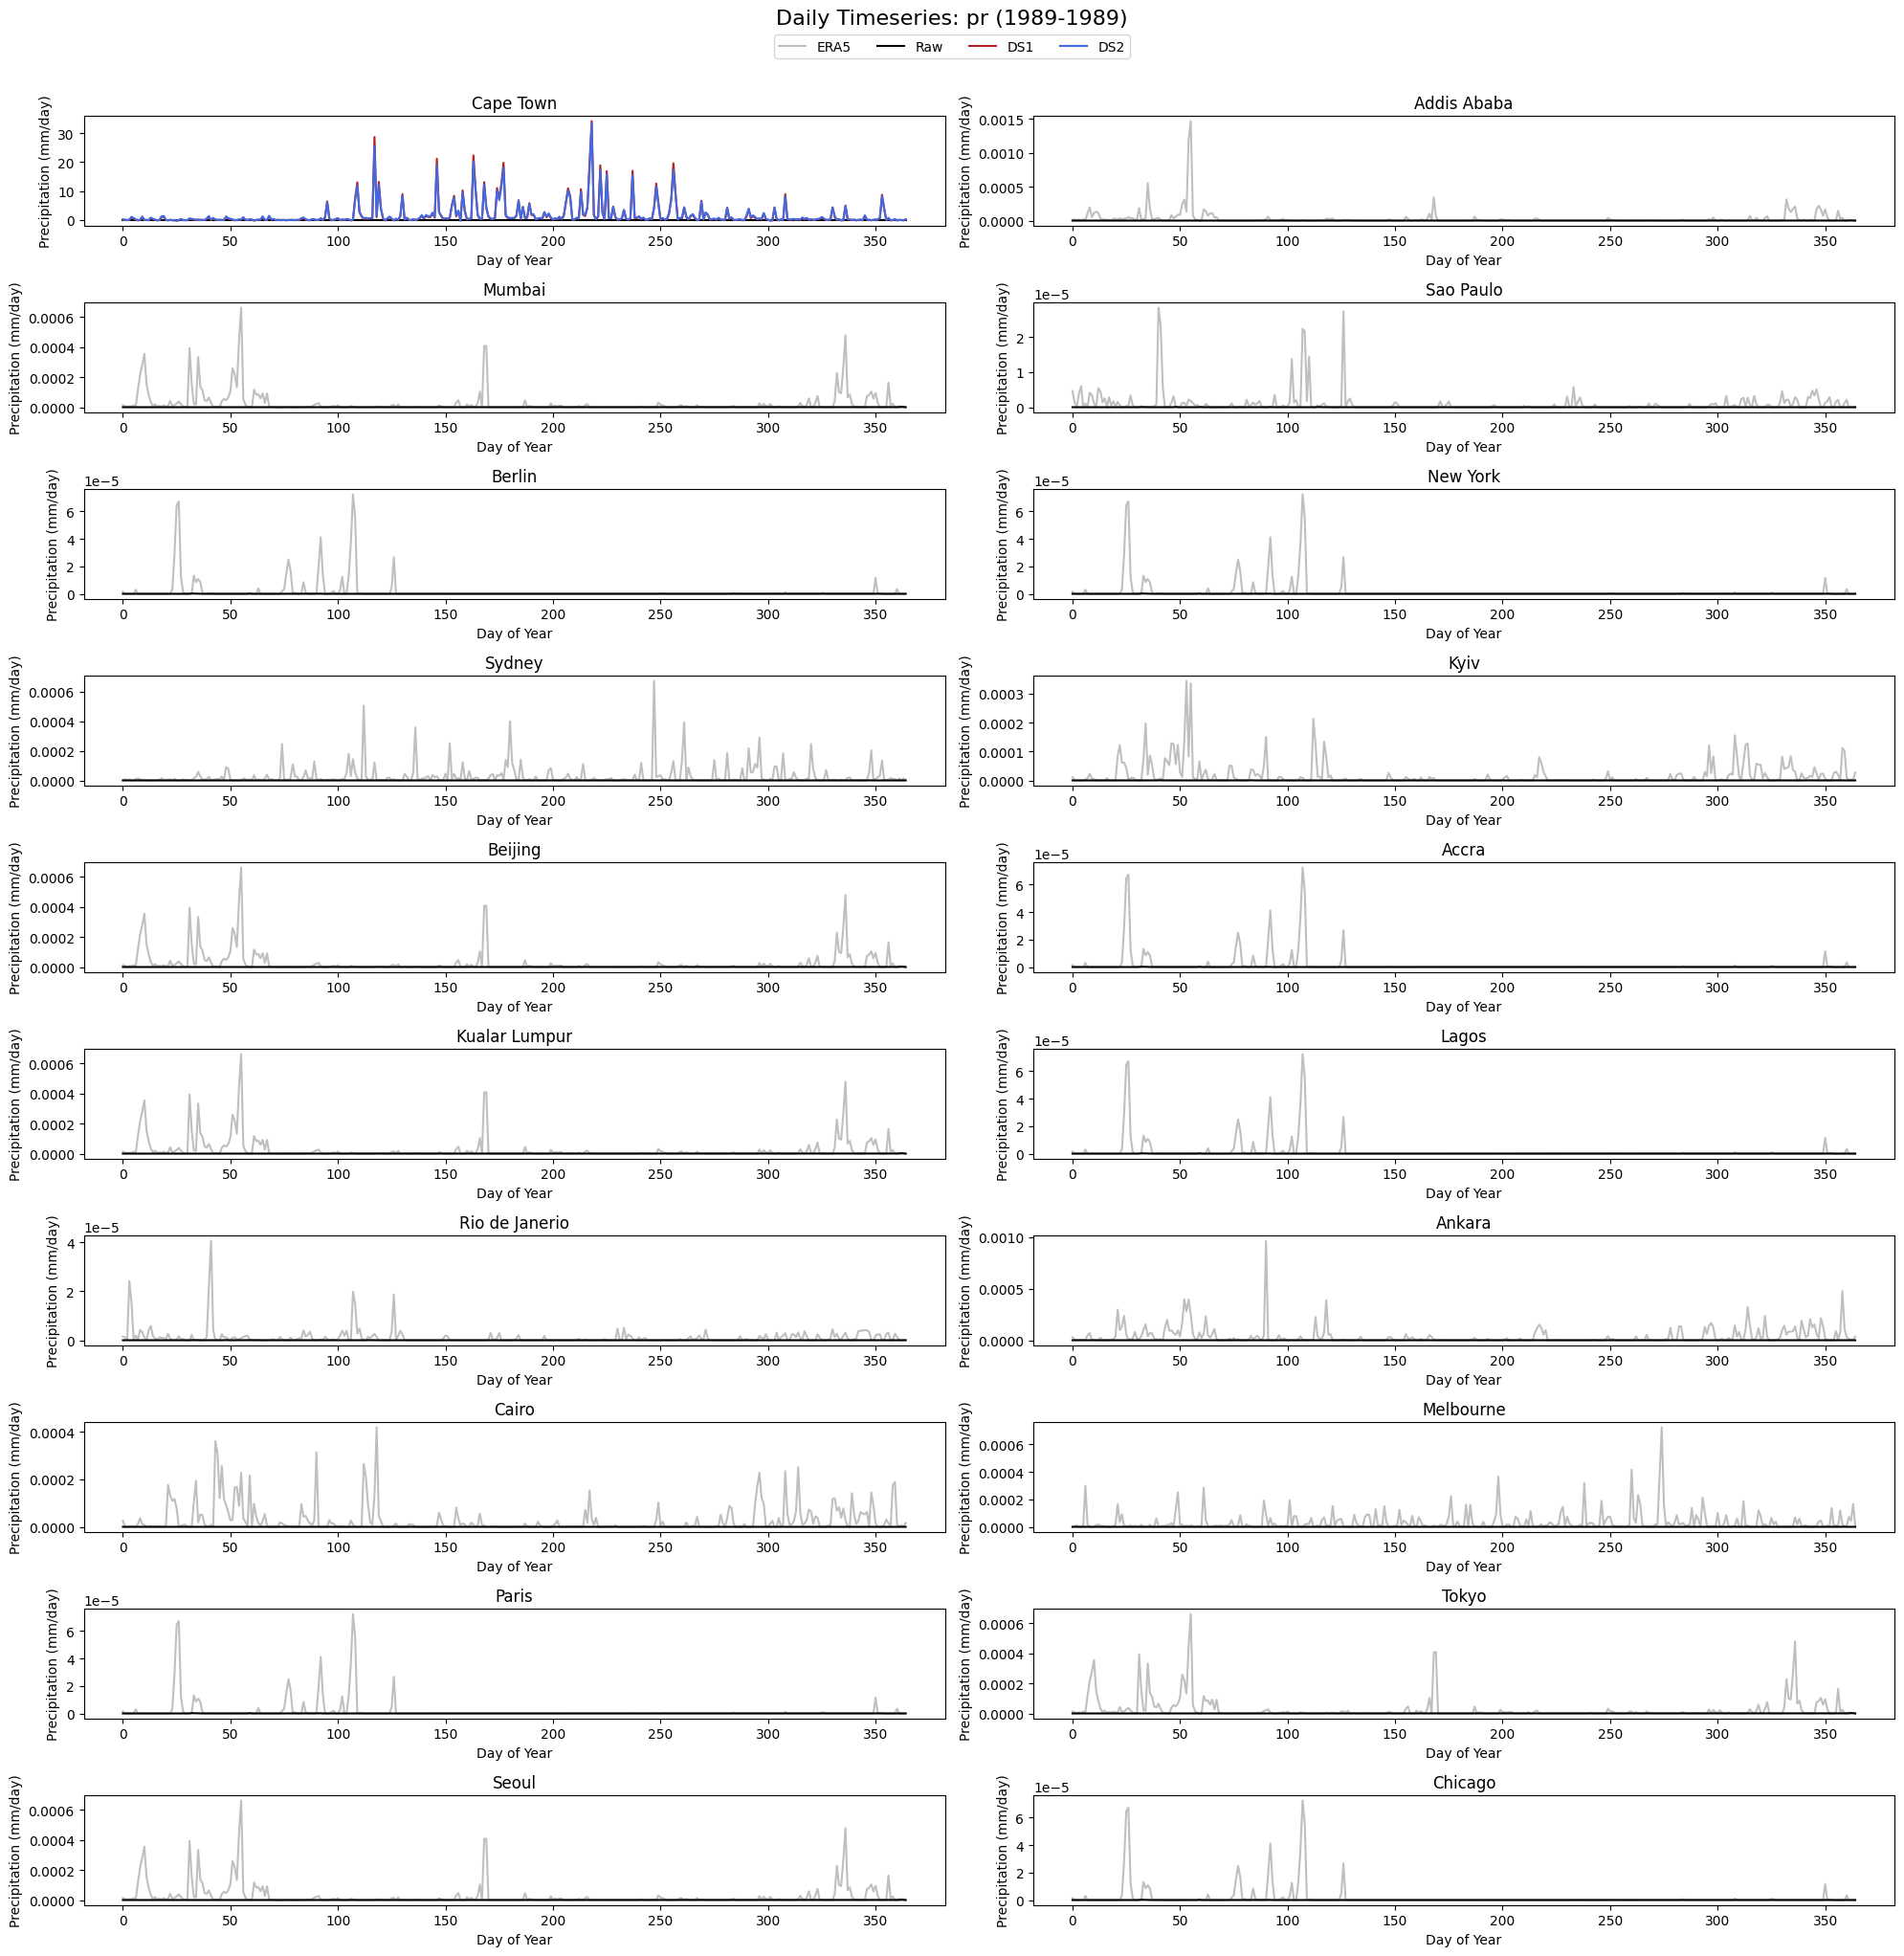

In [34]:
variable = 'pr'
time_slice = slice('1989', '1989')

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20,20))
axarr = axarr_shape.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    # First select time, THEN select point with method='nearest'
    era5_sub = era5.sel(time=time_slice).sel(lat=lat, lon=lon, method='nearest')
    raw_sub = raw.sel(time=time_slice).sel(lat=lat, lon=lon, method='nearest')
    ds1_sub = ds1.sel(time=time_slice).sel(lat=lat, lon=lon, method='nearest')
    ds2_sub = ds2.sel(time=time_slice).sel(lat=lat, lon=lon, method='nearest')
    
    # Plot using .values to avoid datetime issues
    axarr[i].plot(era5_sub[variable].values, color='grey', alpha=0.5)
    axarr[i].plot(raw_sub[variable].values, color='k')
    axarr[i].plot(ds1_sub[variable].values, color='firebrick')
    axarr[i].plot(ds2_sub[variable].values, color='royalblue')
    
    axarr[i].set_title(location)
    axarr[i].set_ylabel('Precipitation (mm/day)')
    axarr[i].set_xlabel('Day of Year')

fig.suptitle(f'Daily Timeseries: {variable} ({time_slice.start}-{time_slice.stop})', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [35]:
# era5_toplot = sel_point(era5, lat, lon)[variable]
# raw_toplot = sel_point(raw, lat, lon)[variable]
# ds1_toplot = sel_point(ds1, lat, lon)[variable]
# ds2_toplot = sel_point(ds2, lat, lon)[variable]
# selected_location = 'Cape Town'
# lat, lon = locations[selected_location]

# era5_toplot = era5.sel(lat=lat, lon=lon, method='nearest')[variable]
# raw_toplot = raw.sel(lat=lat, lon=lon, method='nearest')[variable]
# ds1_toplot = ds1.sel(lat=lat, lon=lon, method='nearest')[variable]
# ds2_toplot = ds2.sel(lat=lat, lon=lon, method='nearest')[variable]

# print(f"Selected location: {selected_location} (lat={lat}, lon={lon})")

selected_location = 'Cape Town'
lat, lon = locations[selected_location]

era5_toplot = era5.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
raw_toplot = raw.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
ds1_toplot = ds1.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
ds2_toplot = ds2.sel(lat=lat, lon=lon, method='nearest')[variable].compute()

# Filter to wet days only (> 0.1 mm/day) for better visualization
threshold = 0.01
era5_toplot = era5_toplot.where(era5_toplot > threshold, drop=True)
raw_toplot = raw_toplot.where(raw_toplot > threshold, drop=True)
ds1_toplot = ds1_toplot.where(ds1_toplot > threshold, drop=True)
ds2_toplot = ds2_toplot.where(ds2_toplot > threshold, drop=True)

print(f"Selected location: {selected_location} (lat={lat}, lon={lon})")
print(f"Filtered to wet days (>{threshold} mm/day)")

Selected location: Cape Town (lat=-33.9221, lon=18.4231)
Filtered to wet days (>0.01 mm/day)


In [36]:
era5_global = icechunk_store_to_dataset("ERA5", catalog)
era5_global = era5_global.sel(time=training_period)
era5_global['pr'] = convert_precip_units(era5_global['pr'], 'ERA5')

raw_global = icechunk_store_to_dataset(dataset_name, catalog)
raw_global = raw_global.sel(time=training_period)
raw_global['pr'] = convert_precip_units(raw_global['pr'], 'CESM2-WACCM')

print("Loaded global ERA5 and raw for PDF/CDF analysis")
print("Converted precipitation to mm/day")
print(f"ERA5 pr max: {float(era5_global['pr'].max()):.2f} mm/day")
print(f"Raw pr max: {float(raw_global['pr'].max()):.2f} mm/day")

Loaded global ERA5 and raw for PDF/CDF analysis
Converted precipitation to mm/day
ERA5 pr max: 757.07 mm/day
Raw pr max: 469.04 mm/day


In [ ]:
def extract_location_data(era5, raw, ds1, ds2, lat, lon, variable, filter_precip=True, threshold=0.1):
    """
    Extract data for a location. Returns None for datasets without coverage.
    For precipitation, optionally filters to wet days only.
    """
    result = {}
    
    # ERA5
    try:
        data = era5.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
        if filter_precip and variable == 'pr':
            data = data.where(data > threshold, drop=True)
        result['era5'] = data
    except Exception as e:
        print(f"ERA5 error for {lat}, {lon}: {e}")
        result['era5'] = None
    
    # Raw GCM
    try:
        data = raw.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
        if filter_precip and variable == 'pr':
            data = data.where(data > threshold, drop=True)
        result['raw'] = data
    except Exception as e:
        print(f"Raw error for {lat}, {lon}: {e}")
        result['raw'] = None
    
    # DS1
    try:
        data = ds1.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
        if filter_precip and variable == 'pr':
            data = data.where(data > threshold, drop=True)
        result['ds1'] = data
    except Exception as e:
        result['ds1'] = None
    
    # DS2
    try:
        data = ds2.sel(lat=lat, lon=lon, method='nearest')[variable].compute()
        if filter_precip and variable == 'pr':
            data = data.where(data > threshold, drop=True)
        result['ds2'] = data
    except Exception as e:
        result['ds2'] = None
    
    return result

print("extract_location_data function defined")

In [ ]:
# PDF - Precipitation (all locations)
variable = 'pr'
threshold = 0.1

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1, ds2, lat, lon, variable, filter_precip=True, threshold=threshold)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            ax.hist(data['era5'].values, bins=50, alpha=0.5, color='grey', density=True, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            ax.hist(data['raw'].values, bins=50, alpha=0.5, color='k', density=True, label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            ax.hist(data['ds1'].values, bins=50, alpha=0.5, color='firebrick', density=True, label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            ax.hist(data['ds2'].values, bins=50, alpha=0.5, color='royalblue', density=True, label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Precipitation (mm/day)')
        ax.set_ylabel('Density')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle(f'PDF of Daily Precipitation (wet days > {threshold} mm/day)', fontsize=16, y=1.02)
#fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
variable = 'tasmin'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            ax.hist(data['era5'].values, bins=50, alpha=0.5, color='grey', density=True, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            ax.hist(data['raw'].values, bins=50, alpha=0.5, color='k', density=True, label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            ax.hist(data['ds1'].values, bins=50, alpha=0.5, color='firebrick', density=True, label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            ax.hist(data['ds2'].values, bins=50, alpha=0.5, color='royalblue', density=True, label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel('Density')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle('PDF of Daily Minimum Temperature', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
variable = 'tasmax'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            ax.hist(data['era5'].values, bins=50, alpha=0.5, color='grey', density=True, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            ax.hist(data['raw'].values, bins=50, alpha=0.5, color='black', density=True, label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            ax.hist(data['ds1'].values, bins=50, alpha=0.5, color='red', density=True, label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            ax.hist(data['ds2'].values, bins=50, alpha=0.5, color='blue', density=True, label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel('Density')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle('PDF of Daily Maximum Temperature', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
variable = 'tas'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            ax.hist(data['era5'].values, bins=50, alpha=0.5, color='grey', density=True, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            ax.hist(data['raw'].values, bins=50, alpha=0.5, color='black', density=True, label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            ax.hist(data['ds1'].values, bins=50, alpha=0.5, color='red', density=True, label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            ax.hist(data['ds2'].values, bins=50, alpha=0.5, color='blue', density=True, label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel('Density')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle('PDF of Daily Mean Temperature', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
#A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.

In [ ]:
# CDF - Precipitation
variable = 'pr'
threshold = 0.1

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1, ds2, lat, lon, variable, filter_precip=True, threshold=threshold)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            sorted_data = np.sort(data['era5'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='grey', alpha=0.7, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            sorted_data = np.sort(data['raw'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='k', label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            sorted_data = np.sort(data['ds1'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='firebrick', label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            sorted_data = np.sort(data['ds2'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='royalblue', label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Precipitation (mm/day)')
        ax.set_ylabel('CDF')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle(f'CDF of Daily Precipitation (wet days > {threshold} mm/day)', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
# CDF - Minimum Temperature (all locations)
variable = 'tasmin'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            sorted_data = np.sort(data['era5'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='grey', alpha=0.7, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            sorted_data = np.sort(data['raw'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='k', label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            sorted_data = np.sort(data['ds1'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='firebrick', label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            sorted_data = np.sort(data['ds2'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='royalblue', label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel('CDF')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle('CDF of Daily Minimum Temperature', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
# CDF - Maximum Temperature (all locations)
variable = 'tasmax'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            sorted_data = np.sort(data['era5'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='grey', alpha=0.7, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            sorted_data = np.sort(data['raw'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='k', label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            sorted_data = np.sort(data['ds1'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='firebrick', label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            sorted_data = np.sort(data['ds2'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='royalblue', label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel('CDF')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle('CDF of Daily Maximum Temperature', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
# CDF - Mean Temperature (all locations)
variable = 'tas'

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]
    
    try:
        data = extract_location_data(era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False)
        
        has_data = False
        if data['era5'] is not None and len(data['era5']) > 0:
            sorted_data = np.sort(data['era5'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='grey', alpha=0.7, label='ERA5')
            has_data = True
        if data['raw'] is not None and len(data['raw']) > 0:
            sorted_data = np.sort(data['raw'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='k', label='Raw')
            has_data = True
        if data['ds1'] is not None and len(data['ds1']) > 0:
            sorted_data = np.sort(data['ds1'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='firebrick', label='DS1')
            has_data = True
        if data['ds2'] is not None and len(data['ds2']) > 0:
            sorted_data = np.sort(data['ds2'].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color='royalblue', label='DS2')
            has_data = True
        
        if not has_data:
            ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(location)
        ax.set_xlabel('Temperature (K)')
        ax.set_ylabel('CDF')
        
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle('CDF of Daily Mean Temperature', fontsize=16, y=1.02)
fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [ ]:
# temi TODO: make a function which create a 20-panel plot like the timeseries above, but each panel is the PDF below.
plot_pdf(era5_toplot, raw_toplot, ds1_toplot, 'pr', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Precipitation at Coarse Resolution")

In [ ]:
# temi TODO: repeat the PDF figures (and update/extend the `plot_pdf` function as needed) for tasmax, tasmin, tas 

In [ ]:
plot_pdf(era5_toplot, raw_toplot, ds1_toplot, 'tasmin', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Minimum Temperature at Coarse Resolution")

In [ ]:
plot_pdf(era5_toplot, raw_toplot, ds1_toplot, 'tasmax', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Maximum Temperature at Coarse Resolution")

In [ ]:
plot_pdf(era5_toplot, raw_toplot, ds1_toplot, 'tas', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Mean Temperature at Coarse Resolution")

A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.

In [ ]:
plot_cdf(era5_toplot, raw_toplot, ds1_toplot, 'pr', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Precipitation at Coarse Resolution")

In [ ]:
plot_cdf(era5_toplot, raw_toplot, ds1_toplot, 'tasmin', ds2=ds2_toplot, title="Distribution of Historical Daily" \
                                                                "Minimum Temperature at Coarse Resolution")

In [ ]:
plot_cdf(era5_toplot, raw_toplot, ds1_toplot, 'tasmax', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Maximum Temperature at Coarse Resolution")

In [ ]:
plot_cdf(era5_toplot, raw_toplot, ds1_toplot, 'tas', ds2=ds2_toplot, title="Distribution of Historical Daily"\
                                                                "Mean Temperature at Coarse Resolution")